<a href="https://colab.research.google.com/github/Iqra171/ACO/blob/main/ACO__Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐜 Ant Colony Optimization — Adaptive Multi-Agent Simulation

This notebook demonstrates ACO with three layers of sophistication:

| Part | Concept | Why it matters |
|---|---|---|
| 1 | Classic ACO (TSP + Grid) | Baseline: emergent behavior from local rules |
| 2 | **Data Assimilation** | Inject noisy observations to correct the pheromone map in real time |
| 3 | **Dynamic Re-planning** | Mid-run environment change forces the colony to adapt |
| 4 | **Parallel Parameter Sweep** | Scale the simulation using multiprocessing |

> *Framed around: dynamic data-driven simulation, online model calibration, and parallel simulation execution.*

In [1]:
!pip install matplotlib numpy -q
print('✅ Ready')

✅ Ready


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from multiprocessing import Pool
import time
np.random.seed(42)
print('✅ Imports done')

✅ Imports done


## Part 1 — Classic ACO: TSP + Grid Pathfinding
Establishes the baseline before we add adaptive layers.

In [3]:
# ── ACO for TSP ──────────────────────────────────────────────
class ACO_TSP:
    def __init__(self, cities, n_ants=30, n_iterations=100,
                 alpha=1.0, beta=2.0, evaporation=0.3, Q=100):
        self.cities = cities
        self.n_cities = len(cities)
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        self.alpha = alpha
        self.beta = beta
        self.evaporation = evaporation
        self.Q = Q
        self.dist = np.zeros((self.n_cities, self.n_cities))
        for i in range(self.n_cities):
            for j in range(self.n_cities):
                if i != j:
                    self.dist[i,j] = np.linalg.norm(cities[i]-cities[j])
        with np.errstate(divide='ignore'):
            self.heuristic = np.where(self.dist>0, 1.0/self.dist, 0)
        self.pheromone = np.ones((self.n_cities, self.n_cities))
        self.best_path = None
        self.best_distance = np.inf
        self.history = []

    def _select_next(self, current, visited):
        unvisited = [c for c in range(self.n_cities) if c not in visited]
        if not unvisited: return None
        scores = np.array([
            (self.pheromone[current,j]**self.alpha)*(self.heuristic[current,j]**self.beta)
            for j in unvisited])
        total = scores.sum()
        probs = scores/total if total>0 else np.ones(len(unvisited))/len(unvisited)
        return unvisited[np.random.choice(len(unvisited), p=probs)]

    def _path_distance(self, path):
        return sum(self.dist[path[i],path[i+1]] for i in range(len(path)-1)) + self.dist[path[-1],path[0]]

    def run(self, verbose=False):
        for it in range(self.n_iterations):
            paths, dists = [], []
            for _ in range(self.n_ants):
                start = np.random.randint(self.n_cities)
                path, visited = [start], {start}
                while len(path) < self.n_cities:
                    nxt = self._select_next(path[-1], visited)
                    if nxt is None: break
                    path.append(nxt); visited.add(nxt)
                d = self._path_distance(path)
                paths.append(path); dists.append(d)
                if d < self.best_distance:
                    self.best_distance = d; self.best_path = path[:]
            self.pheromone *= (1-self.evaporation)
            for path, d in zip(paths, dists):
                dep = self.Q/d
                for i in range(len(path)-1):
                    self.pheromone[path[i],path[i+1]] += dep
                    self.pheromone[path[i+1],path[i]] += dep
                self.pheromone[path[-1],path[0]] += dep
                self.pheromone[path[0],path[-1]] += dep
            self.history.append(self.best_distance)
            if verbose and (it+1)%10==0:
                print(f'  Iter {it+1:3d} | Best: {self.best_distance:.2f}')
        return self.best_path, self.best_distance

N_CITIES = 20
cities = np.random.rand(N_CITIES, 2) * 100
aco = ACO_TSP(cities, n_ants=30, n_iterations=100)
best_path, best_dist = aco.run(verbose=True)
print(f'\n🐜 Best distance: {best_dist:.2f}')

  Iter  10 | Best: 399.46
  Iter  20 | Best: 393.25
  Iter  30 | Best: 388.39
  Iter  40 | Best: 386.63
  Iter  50 | Best: 386.63
  Iter  60 | Best: 386.63
  Iter  70 | Best: 386.63
  Iter  80 | Best: 386.63
  Iter  90 | Best: 386.63
  Iter 100 | Best: 386.63

🐜 Best distance: 386.63


/tmp/ipykernel_425/585234544.py:28: UserWarning: Glyph 128028 (\N{ANT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_425/585234544.py:29: UserWarning: Glyph 128028 (\N{ANT}) missing from font(s) DejaVu Sans.
  plt.savefig('aco_tsp.png', dpi=150, bbox_inches='tight', facecolor='#0d0f14')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128028 (\N{ANT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


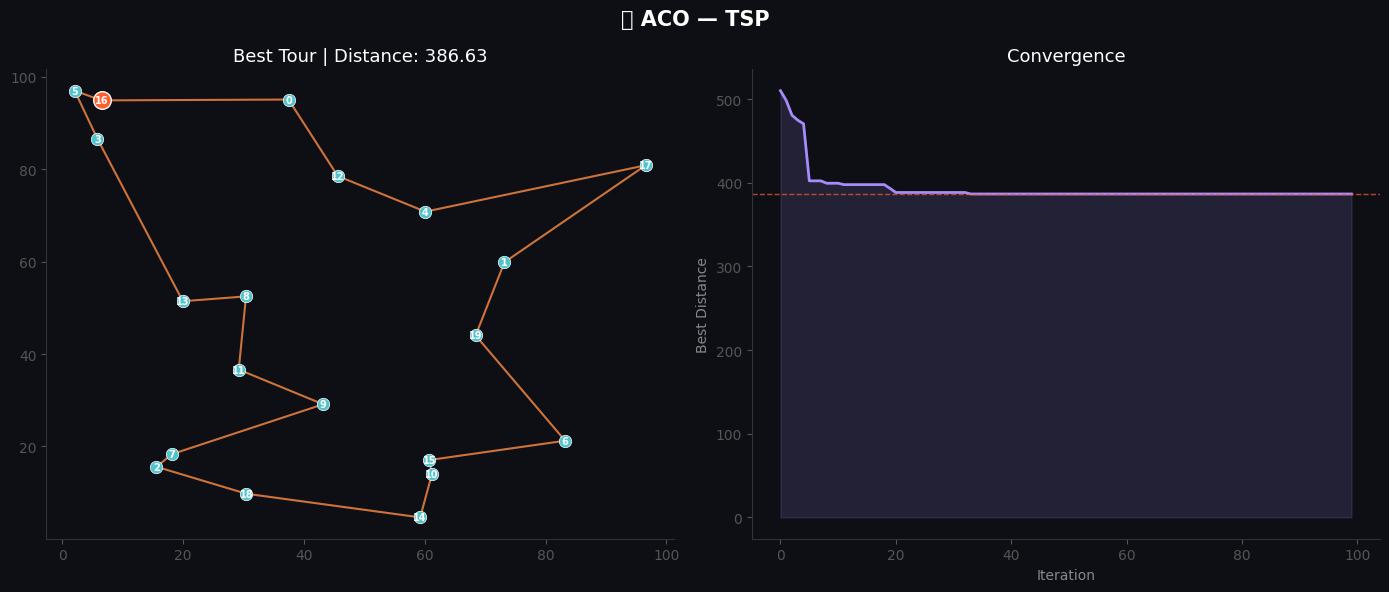

In [4]:
# ── Visualize TSP result ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d0f14')
for ax in axes: ax.set_facecolor('#0d0f14')

ax1 = axes[0]
path = best_path + [best_path[0]]
xs = [cities[i,0] for i in path]; ys = [cities[i,1] for i in path]
ax1.plot(xs, ys, '-', color='#ff8c42', linewidth=1.5, alpha=0.8)
ax1.scatter(cities[:,0], cities[:,1], s=80, color='#4fc4cf', zorder=3, edgecolors='white', linewidths=0.5)
ax1.scatter(cities[best_path[0],0], cities[best_path[0],1], s=160, color='#ff5e2c', zorder=4, edgecolors='white')
for i,(x,y) in enumerate(cities):
    ax1.annotate(str(i),(x,y),fontsize=7,color='white',ha='center',va='center',fontweight='bold',zorder=5)
ax1.set_title(f'Best Tour | Distance: {best_dist:.2f}', color='white', fontsize=13)
ax1.tick_params(colors='#555'); [ax1.spines[s].set_color('#333') for s in ['bottom','left']]
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2 = axes[1]
ax2.plot(aco.history, color='#a78bfa', linewidth=2)
ax2.fill_between(range(len(aco.history)), aco.history, alpha=0.15, color='#a78bfa')
ax2.axhline(y=best_dist, color='#ff5e2c', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_title('Convergence', color='white', fontsize=13)
ax2.set_xlabel('Iteration', color='#888'); ax2.set_ylabel('Best Distance', color='#888')
ax2.tick_params(colors='#555'); [ax2.spines[s].set_color('#333') for s in ['bottom','left']]
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('🐜 ACO — TSP', color='white', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('aco_tsp.png', dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()

## Part 2 — Data Assimilation: Correcting the Pheromone Map with Noisy Observations

**The problem:** In a real deployment, you don't perfectly observe the environment.
Sensors are noisy. How do you keep the simulation accurate?

**The solution:** At regular intervals, inject noisy 'sensor observations' of edge quality
and use a weighted correction (Bayesian update) to adjust the pheromone map.
This is the core idea behind *online model calibration in simulation*.

```
Every 10 iterations:
  observed_pheromone = true_pheromone + Gaussian_noise
  corrected = (1 - gain) * model_estimate + gain * observation
```
The **gain** controls how much we trust the sensor vs the model — a key calibration parameter.

In [5]:
# ── ACO with Data Assimilation ────────────────────────────────
class ACO_DataAssimilation(ACO_TSP):
    """
    Extends ACO_TSP with a Bayesian-style pheromone correction step.
    Every `assimilation_interval` iterations, noisy observations of
    edge quality are injected and used to correct the pheromone map.
    """
    def __init__(self, *args, assimilation_interval=10,
                 obs_noise=0.3, gain=0.25, **kwargs):
        super().__init__(*args, **kwargs)
        self.assimilation_interval = assimilation_interval
        self.obs_noise = obs_noise   # sensor noise std
        self.gain = gain             # how much we trust observation vs model
        self.assimilation_events = []
        self.history_no_da = []      # track a parallel run without DA for comparison

    def _get_observation(self):
        """Simulate a noisy sensor reading of the pheromone map."""
        noise = np.random.normal(0, self.obs_noise, self.pheromone.shape)
        return np.clip(self.pheromone + noise * self.pheromone, 0.01, None)

    def _assimilate(self, iteration):
        """Bayesian-style weighted update: blend model state with observation."""
        observation = self._get_observation()
        self.pheromone = (1 - self.gain) * self.pheromone + self.gain * observation
        self.assimilation_events.append(iteration)

    def run(self, verbose=False):
        for it in range(self.n_iterations):
            paths, dists = [], []
            for _ in range(self.n_ants):
                start = np.random.randint(self.n_cities)
                path, visited = [start], {start}
                while len(path) < self.n_cities:
                    nxt = self._select_next(path[-1], visited)
                    if nxt is None: break
                    path.append(nxt); visited.add(nxt)
                d = self._path_distance(path)
                paths.append(path); dists.append(d)
                if d < self.best_distance:
                    self.best_distance = d; self.best_path = path[:]
            self.pheromone *= (1 - self.evaporation)
            for path, d in zip(paths, dists):
                dep = self.Q/d
                for i in range(len(path)-1):
                    self.pheromone[path[i],path[i+1]] += dep
                    self.pheromone[path[i+1],path[i]] += dep
                self.pheromone[path[-1],path[0]] += dep
                self.pheromone[path[0],path[-1]] += dep

            # ── DATA ASSIMILATION STEP ──
            if (it+1) % self.assimilation_interval == 0:
                self._assimilate(it)

            self.history.append(self.best_distance)
            if verbose and (it+1)%10==0:
                da_marker = ' ← assimilated' if it in self.assimilation_events else ''
                print(f'  Iter {it+1:3d} | Best: {self.best_distance:.2f}{da_marker}')
        return self.best_path, self.best_distance

# Run both: with and without data assimilation
np.random.seed(42)
aco_plain = ACO_TSP(cities, n_ants=30, n_iterations=100, alpha=1.0, beta=2.0)
aco_plain.run()

np.random.seed(42)
aco_da = ACO_DataAssimilation(cities, n_ants=30, n_iterations=100,
                               alpha=1.0, beta=2.0,
                               assimilation_interval=10, obs_noise=0.2, gain=0.2)
aco_da.run(verbose=True)

print(f'\nPlain ACO final:          {aco_plain.best_distance:.2f}')
print(f'ACO + Data Assimilation:  {aco_da.best_distance:.2f}')

  Iter  10 | Best: 398.38 ← assimilated
  Iter  20 | Best: 397.70 ← assimilated
  Iter  30 | Best: 396.53 ← assimilated
  Iter  40 | Best: 386.43 ← assimilated
  Iter  50 | Best: 386.43 ← assimilated
  Iter  60 | Best: 386.43 ← assimilated
  Iter  70 | Best: 386.43 ← assimilated
  Iter  80 | Best: 386.43 ← assimilated
  Iter  90 | Best: 386.43 ← assimilated
  Iter 100 | Best: 386.43 ← assimilated

Plain ACO final:          386.63
ACO + Data Assimilation:  386.43


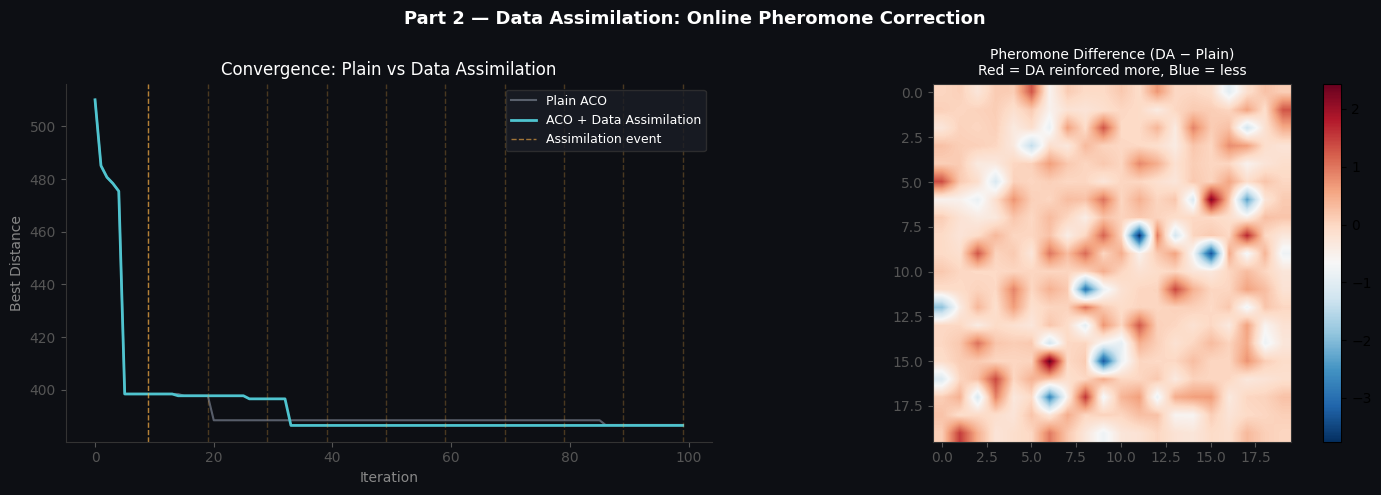

Saved → aco_da.png


In [6]:
# ── Visualize: DA vs Plain convergence ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d0f14')
for ax in axes: ax.set_facecolor('#0d0f14')

# Left: convergence comparison
ax1 = axes[0]
ax1.plot(aco_plain.history, color='#6b7280', linewidth=1.5, label='Plain ACO', alpha=0.8)
ax1.plot(aco_da.history, color='#4fc4cf', linewidth=2, label='ACO + Data Assimilation')
for ev in aco_da.assimilation_events:
    ax1.axvline(x=ev, color='#ffb347', alpha=0.25, linewidth=1, linestyle='--')
ax1.axvline(x=aco_da.assimilation_events[0], color='#ffb347', alpha=0.6,
            linewidth=1, linestyle='--', label='Assimilation event')
ax1.set_title('Convergence: Plain vs Data Assimilation', color='white', fontsize=12)
ax1.set_xlabel('Iteration', color='#888'); ax1.set_ylabel('Best Distance', color='#888')
ax1.legend(facecolor='#1a1d26', edgecolor='#333', labelcolor='white', fontsize=9)
ax1.tick_params(colors='#555')
[ax1.spines[s].set_color('#333') for s in ['bottom','left']]
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Right: pheromone state comparison at end
ax2 = axes[1]
ph_plain = aco_plain.pheromone.copy(); np.fill_diagonal(ph_plain, 0)
ph_da    = aco_da.pheromone.copy();    np.fill_diagonal(ph_da, 0)
diff = ph_da - ph_plain
im = ax2.imshow(diff, cmap='RdBu_r', interpolation='bilinear')
plt.colorbar(im, ax=ax2, fraction=0.046)
ax2.set_title('Pheromone Difference (DA − Plain)\nRed = DA reinforced more, Blue = less',
              color='white', fontsize=10)
ax2.tick_params(colors='#555')
[ax2.spines[s].set_color('#333') for s in ax2.spines]

plt.suptitle('Part 2 — Data Assimilation: Online Pheromone Correction',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('aco_da.png', dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('Saved → aco_da.png')

## Part 3 — Dynamic Re-planning: Environment Changes Mid-Simulation

**The problem:** Real environments are not static. Paths get blocked. Conditions shift.
A robust multi-agent system must detect and adapt — not just optimize for a fixed world.

**What happens here:**
- The colony builds pheromone trails on a 30×30 grid for 40 iterations
- At iteration 40, a **new wall obstacle appears**, blocking the current best path
- The colony must re-explore and find a new route using only pheromone decay + local sensing
- No global reset — agents adapt purely through the stigmergic mechanism

In [7]:
# ── Grid ACO with dynamic obstacle injection ──────────────────
GRID = 30
NEST = (2, 2)
FOOD = (27, 27)
CHANGE_AT = 40   # iteration when new obstacle appears
N_ANTS = 60
N_ITERS = 100
EVAP = 0.12
ALPHA, BETA = 1.2, 1.5

def make_base_grid():
    g = np.ones((GRID, GRID))
    g[10:22, 12:14] = 0   # wall 1
    g[8:20, 18:20]  = 0   # wall 2
    return g

def get_neighbors(r, c, grid):
    neighbors = []
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
        nr, nc = r+dr, c+dc
        if 0<=nr<GRID and 0<=nc<GRID and grid[nr,nc]==1:
            neighbors.append((nr,nc))
    return neighbors

def ant_walk(pheromone, grid):
    r, c = NEST
    path, visited = [(r,c)], {(r,c)}
    food_r, food_c = FOOD
    for _ in range(GRID*GRID):
        if (r,c) == FOOD: return path
        neighbors = [(nr,nc) for nr,nc in get_neighbors(r,c,grid) if (nr,nc) not in visited]
        if not neighbors: return None
        scores = []
        for nr,nc in neighbors:
            dist_heur = (1.0/(abs(nr-food_r)+abs(nc-food_c)+1))**BETA
            scores.append((pheromone[nr,nc]**ALPHA)*dist_heur)
        scores = np.array(scores); probs = scores/scores.sum()
        r,c = neighbors[np.random.choice(len(neighbors), p=probs)]
        path.append((r,c)); visited.add((r,c))
    return None

grid = make_base_grid()
pheromone = np.ones((GRID,GRID)) * 0.1
best_path_grid, best_len = None, np.inf
history_dynamic = []
snapshots = {}   # save pheromone state at key moments
change_applied = False

print('Running dynamic grid ACO...')
for it in range(N_ITERS):

    # ── ENVIRONMENT CHANGE ──
    if it == CHANGE_AT and not change_applied:
        print(f'\n  ⚠️  Iteration {it}: NEW OBSTACLE added — blocking current path!')
        snapshots['before_change'] = (pheromone.copy(), best_path_grid[:])
        grid[5:25, 8:10] = 0   # new blocking wall cuts through common routes
        # Erase pheromone on newly blocked cells to force re-routing
        pheromone[grid == 0] = 0.01
        change_applied = True
        best_len = np.inf   # force colony to find new best
        best_path_grid = None
        print(f'  Colony must re-route from scratch...')

    pheromone *= (1 - EVAP)
    pheromone = np.clip(pheromone, 0.01, None)

    for _ in range(N_ANTS):
        path = ant_walk(pheromone, grid)
        if path and path[-1] == FOOD:
            dep = 100.0 / len(path)
            for r,c in path: pheromone[r,c] += dep
            if len(path) < best_len:
                best_len = len(path); best_path_grid = path

    history_dynamic.append(best_len if best_len < np.inf else None)

    if (it+1)%20==0:
        print(f'  Iter {it+1:3d} | Best path: {best_len} steps')

snapshots['after_change'] = (pheromone.copy(), best_path_grid)
print(f'\n✅ Done | Final best path: {best_len} steps')

Running dynamic grid ACO...
  Iter  20 | Best path: 60 steps
  Iter  40 | Best path: 60 steps

  ⚠️  Iteration 40: NEW OBSTACLE added — blocking current path!
  Colony must re-route from scratch...
  Iter  60 | Best path: 72 steps
  Iter  80 | Best path: 61 steps
  Iter 100 | Best path: 61 steps

✅ Done | Final best path: 61 steps


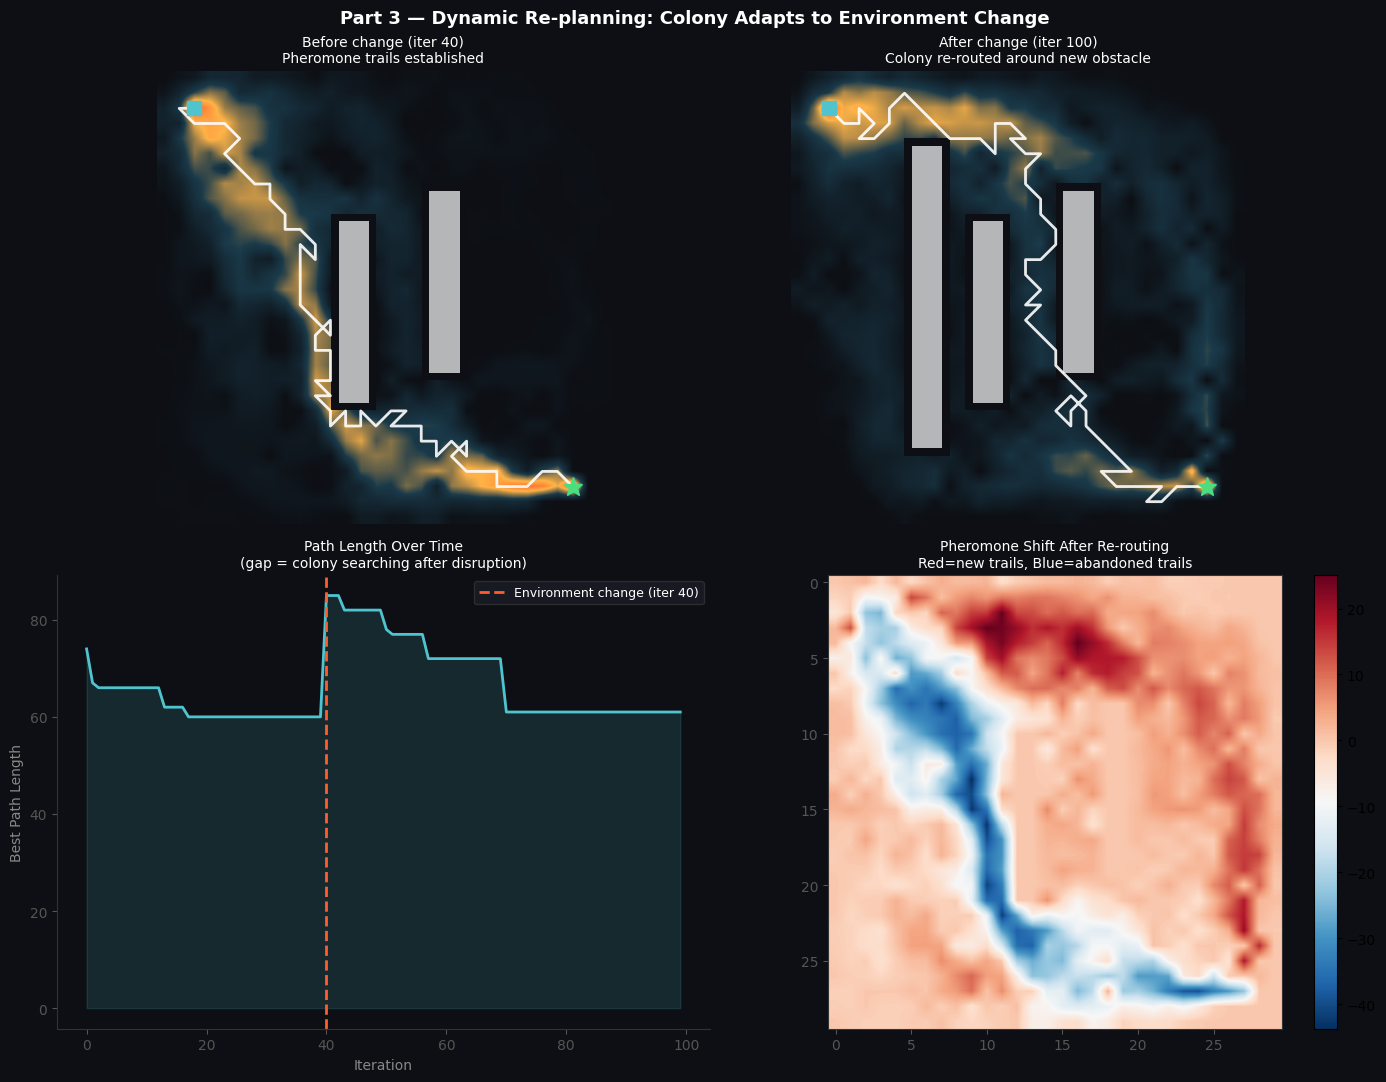

Saved → aco_dynamic.png


In [8]:
# ── Visualize dynamic re-planning ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.patch.set_facecolor('#0d0f14')
for row in axes:
    for ax in row: ax.set_facecolor('#0d0f14')

ph_cmap = LinearSegmentedColormap.from_list('ph', ['#0d0f14','#1a3a4a','#ffb347','#ff5e2c'])

def draw_grid_state(ax, ph, path, grid_state, title):
    display = np.where(grid_state==0, np.nan, ph)
    ax.imshow(display, cmap=ph_cmap, interpolation='bilinear', vmin=0)
    # draw obstacles
    obstacle = np.ma.masked_where(grid_state!=0, np.ones_like(grid_state))
    ax.imshow(obstacle, cmap='gray', vmin=0, vmax=1, alpha=0.7, interpolation='none')
    if path:
        pr=[p[0] for p in path]; pc=[p[1] for p in path]
        ax.plot(pc, pr, '-', color='white', linewidth=2, alpha=0.9, zorder=4)
    ax.plot(NEST[1],NEST[0],'s',color='#4fc4cf',markersize=10,zorder=5)
    ax.plot(FOOD[1],FOOD[0],'*',color='#4ade80',markersize=14,zorder=5)
    ax.set_title(title, color='white', fontsize=10); ax.axis('off')

base_grid = make_base_grid()
ph_before, path_before = snapshots['before_change']
ph_after, path_after = snapshots['after_change']

draw_grid_state(axes[0][0], ph_before, path_before, base_grid,
                f'Before change (iter {CHANGE_AT})\nPheromone trails established')
draw_grid_state(axes[0][1], ph_after, path_after, grid,
                f'After change (iter {N_ITERS})\nColony re-routed around new obstacle')

# Bottom: convergence with change marker
ax_conv = axes[1][0]
clean_hist = [v if v is not None else np.nan for v in history_dynamic]
ax_conv.plot(clean_hist, color='#4fc4cf', linewidth=2)
ax_conv.fill_between(range(len(clean_hist)), clean_hist, alpha=0.15, color='#4fc4cf')
ax_conv.axvline(x=CHANGE_AT, color='#ff5e2c', linewidth=2, linestyle='--',
                label=f'Environment change (iter {CHANGE_AT})')
ax_conv.set_title('Path Length Over Time\n(gap = colony searching after disruption)',
                  color='white', fontsize=10)
ax_conv.set_xlabel('Iteration', color='#888'); ax_conv.set_ylabel('Best Path Length', color='#888')
ax_conv.legend(facecolor='#1a1d26', edgecolor='#333', labelcolor='white', fontsize=9)
ax_conv.tick_params(colors='#555')
[ax_conv.spines[s].set_color('#333') for s in ['bottom','left']]
ax_conv.spines['top'].set_visible(False); ax_conv.spines['right'].set_visible(False)

# Bottom right: pheromone diff before vs after
ax_diff = axes[1][1]
diff = ph_after - ph_before
im = ax_diff.imshow(diff, cmap='RdBu_r', interpolation='bilinear')
plt.colorbar(im, ax=ax_diff, fraction=0.046)
ax_diff.set_title('Pheromone Shift After Re-routing\nRed=new trails, Blue=abandoned trails',
                  color='white', fontsize=10)
ax_diff.tick_params(colors='#555')
[ax_diff.spines[s].set_color('#333') for s in ax_diff.spines]

plt.suptitle('Part 3 — Dynamic Re-planning: Colony Adapts to Environment Change',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('aco_dynamic.png', dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('Saved → aco_dynamic.png')

## Part 4 — Parallel Parameter Sweep

Instead of testing α/β configs one at a time, we run all 9 simultaneously
using Python `multiprocessing`. This scales the simulation horizontally.

**Why this matters:** Real simulation studies require thousands of runs with varied
parameters to build confidence intervals and sensitivity analyses — sequential
execution is the bottleneck. Parallelism is the standard solution.

In [9]:
# ── Parallel Parameter Sweep ──────────────────────────────────
def run_config(params):
    """Worker function — runs one ACO config, returns (alpha, beta, history, best_dist)."""
    alpha, beta, seed = params
    np.random.seed(seed)
    aco = ACO_TSP(cities, n_ants=20, n_iterations=80, alpha=alpha, beta=beta, evaporation=0.3)
    _, dist = aco.run(verbose=False)
    return (alpha, beta, aco.history, dist)

configs = [(a, b, 42) for a in [0.5, 1.0, 2.0] for b in [1.0, 2.0, 4.0]]

print(f'Launching {len(configs)} configs in parallel...')
t0 = time.time()

# Parallel execution
with Pool(processes=min(4, len(configs))) as pool:
    results = pool.map(run_config, configs)

t1 = time.time()
print(f'✅ All done in {t1-t0:.1f}s')
print(f'\nResults summary:')
print(f'{"α":>6} {"β":>6} {"Best Dist":>12}')
print('-'*28)
for alpha, beta, _, dist in sorted(results, key=lambda x: x[3]):
    print(f'{alpha:>6.1f} {beta:>6.1f} {dist:>12.2f}')

Launching 9 configs in parallel...
✅ All done in 13.7s

Results summary:
     α      β    Best Dist
----------------------------
   1.0    2.0       388.20
   1.0    4.0       388.20
   2.0    2.0       388.39
   2.0    4.0       388.39
   1.0    1.0       389.13
   0.5    4.0       396.53
   0.5    2.0       400.53
   2.0    1.0       400.89
   0.5    1.0       442.14


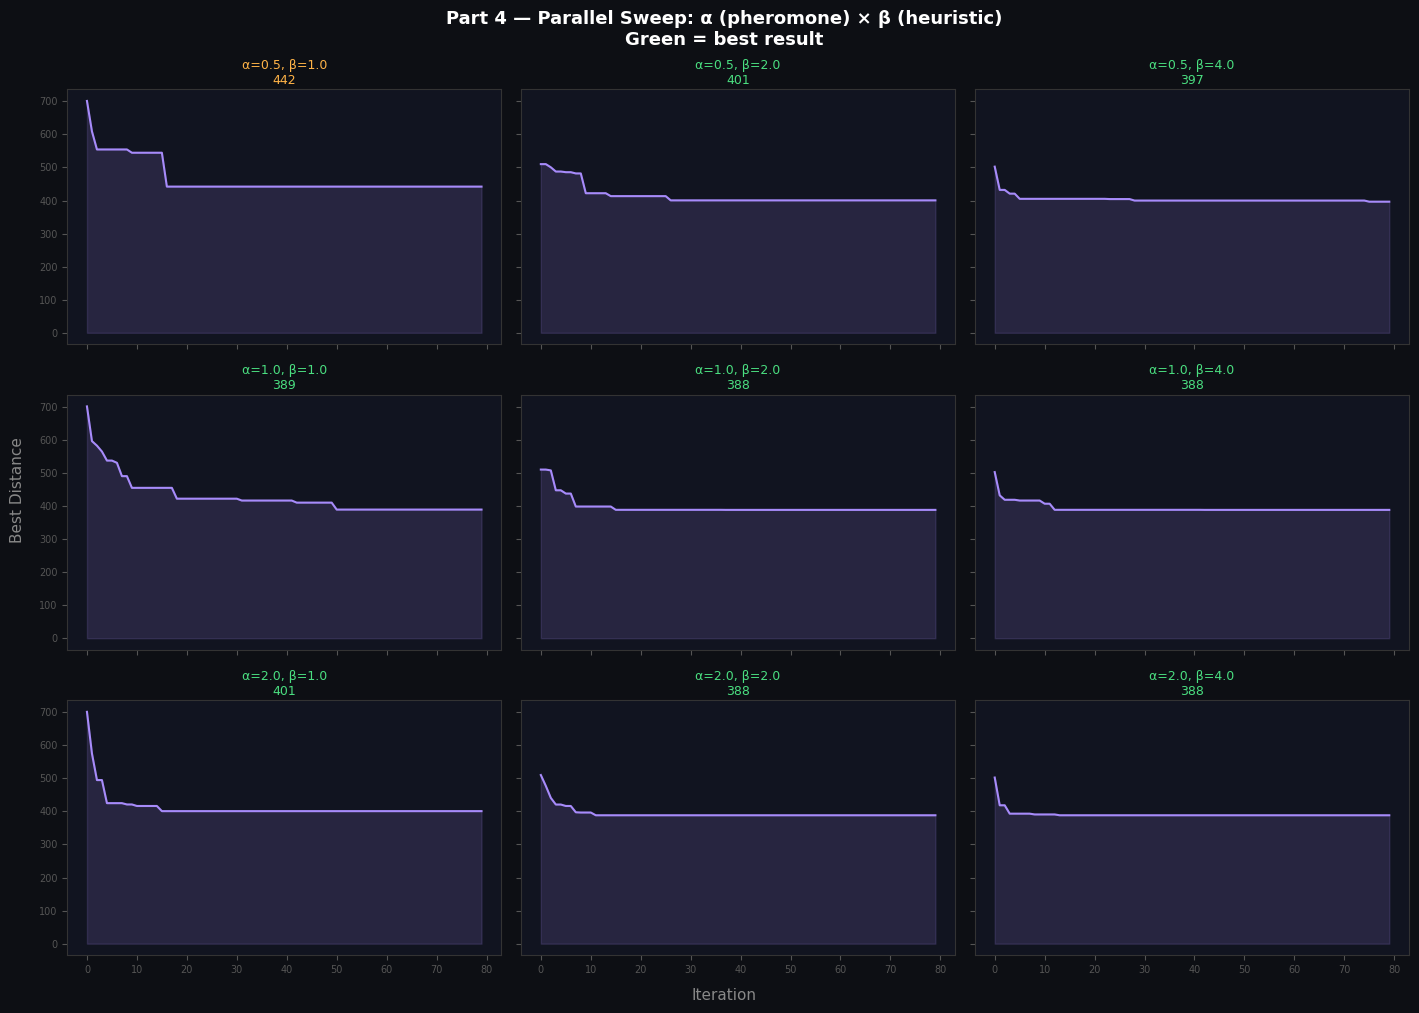

Saved → aco_parallel_sweep.png


In [10]:
# ── Visualize parallel sweep results ─────────────────────────
alphas_u = sorted(set(r[0] for r in results))
betas_u  = sorted(set(r[1] for r in results))

fig, axes = plt.subplots(len(alphas_u), len(betas_u), figsize=(14, 10),
                          sharex=True, sharey=True)
fig.patch.set_facecolor('#0d0f14')

result_map = {(a,b): (hist, dist) for a, b, hist, dist in results}

for i, a in enumerate(alphas_u):
    for j, b in enumerate(betas_u):
        ax = axes[i][j]
        ax.set_facecolor('#111420')
        hist, dist = result_map[(a,b)]
        ax.plot(hist, color='#a78bfa', linewidth=1.5)
        ax.fill_between(range(len(hist)), hist, alpha=0.15, color='#a78bfa')
        color = '#4ade80' if dist < 430 else '#ffb347' if dist < 500 else '#ff5e2c'
        ax.set_title(f'α={a}, β={b}\n{dist:.0f}', color=color, fontsize=9, pad=4)
        [ax.spines[s].set_color('#333') for s in ax.spines]
        ax.tick_params(colors='#555', labelsize=7)

fig.text(0.5, -0.01, 'Iteration', ha='center', color='#888', fontsize=11)
fig.text(-0.01, 0.5, 'Best Distance', va='center', rotation='vertical', color='#888', fontsize=11)
plt.suptitle('Part 4 — Parallel Sweep: α (pheromone) × β (heuristic)\nGreen = best result',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('aco_parallel_sweep.png', dpi=150, bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('Saved → aco_parallel_sweep.png')